In [89]:
import numpy as np
import scipy.stats as stats
import pandas as pd

In [90]:
eval_results = pd.read_csv("../evaluation_results.csv")

In [91]:
eval_results

,id,folder,model,modified_ner,sub_categories,file,path,precision,recall,f1,loose_precision,loose_recall,loose_f1,unlabeled_precision,unlabeled_recall,unlabeled_f1
0,0,gender_names,mono,PER,female,female_names_test_0_results_mono.iob2,../predictions\gender_names\mono\female_names_...,0.684552,0.680476,0.682508,0.837285,0.836765,0.682508,0.725589,0.714412,0.682508
1,1,gender_names,mono,PER,female,female_names_test_1_results_mono.iob2,../predictions\gender_names\mono\female_names_...,0.686078,0.680972,0.683516,0.839290,0.837013,0.683516,0.724969,0.714058,0.683516
2,2,gender_names,mono,PER,female,female_names_test_2_results_mono.iob2,../predictions\gender_names\mono\female_names_...,0.683163,0.681469,0.682315,0.835364,0.837261,0.682315,0.725624,0.715475,0.682315
3,3,gender_names,mono,PER,female,female_names_test_3_results_mono.iob2,../predictions\gender_names\mono\female_names_...,0.685393,0.680972,0.683176,0.837453,0.836269,0.683176,0.724528,0.713881,0.683176
4,4,gender_names,mono,PER,female,female_names_test_4_results_mono.iob2,../predictions\gender_names\mono\female_names_...,0.683803,0.679732,0.681762,0.836536,0.835773,0.681762,0.723810,0.713173,0.681762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,227,typos_loc,multi,LOC,typos,typos_entity_loc_conll_5_results_multi.iob2,../predictions\typos_loc\multi\typos_entity_lo...,0.601017,0.564322,0.582091,0.790474,0.739447,0.582091,0.700165,0.601983,0.582091
228,228,typos_loc,multi,LOC,typos,typos_entity_loc_conll_6_results_multi.iob2,../predictions\typos_loc\multi\typos_entity_lo...,0.602200,0.564070,0.582512,0.792650,0.738945,0.582512,0.699093,0.600567,0.582512
229,229,typos_loc,multi,LOC,typos,typos_entity_loc_conll_7_results_multi.iob2,../predictions\typos_loc\multi\typos_entity_lo...,0.601770,0.563819,0.582177,0.791633,0.737940,0.582177,0.700308,0.603222,0.582177
230,230,typos_loc,multi,LOC,typos,typos_entity_loc_conll_8_results_multi.iob2,../predictions\typos_loc\multi\typos_entity_lo...,0.600374,0.564322,0.581790,0.788292,0.737688,0.581790,0.698622,0.601275,0.581790


In [92]:
eval_results = eval_results[['folder','model','sub_categories','precision','recall','f1','loose_precision','loose_recall','loose_f1','unlabeled_precision','unlabeled_recall','unlabeled_f1']]

In [93]:
eval_results[['folder','sub_categories']].drop_duplicates()

,folder,sub_categories
0,gender_names,female
10,gender_names,male
40,location_exonym_endonym,location
41,location_exonym_endonym,location_latin
44,original_test,test
46,person,african
56,person,american
66,person,arabic
76,person,european
86,person,indian


In [114]:
# person_names = eval_results[eval_results['folder']=='gender_names'  eval_results['folder']=='gender_names']
person_names_all_models = eval_results.loc[
    (eval_results['folder']=='gender_names')    | 
    (eval_results['folder']=='original_test')   |
    (eval_results['folder']=='person')          |
    (eval_results['folder']=='random')          |
    (eval_results['folder']=='typos_entity')    
]

location_names_all_models = eval_results.loc[
    (eval_results['folder']=='location_exonym_endonym')    | 
    (eval_results['folder']=='original_test')   |
    (eval_results['folder']=='typos_loc')
]

context_all_models = eval_results.loc[
    (eval_results['folder']=='pronouns')    | 
    (eval_results['folder']=='typos')   |
    (eval_results['folder']=='original_test')
]

In [280]:
measure = 'f1'
model = 'multi'

# >>> Names
# intermediary
person_names = person_names_all_models[person_names_all_models['model'] == model]
gender_names = person_names[person_names['folder']=='gender_names']
region_names = person_names[person_names['folder']=='person']

fem_names = gender_names[gender_names['sub_categories']=='female'][measure].to_list()
masc_names = gender_names[gender_names['sub_categories']=='male'][measure].to_list()

african_names = region_names[person_names['sub_categories']=='african'][measure].to_list()
american_names = region_names[person_names['sub_categories']=='american'][measure].to_list()
arabic_names = region_names[person_names['sub_categories']=='arabic'][measure].to_list()
european_names = region_names[person_names['sub_categories']=='european'][measure].to_list()
indian_names = region_names[person_names['sub_categories']=='indian'][measure].to_list()

typos_per = person_names[person_names['folder']=='typos_entity'][measure].to_list()
random_per = person_names[person_names['folder']=='random'][measure].to_list()
# original_test = person_names[person_names['folder']=='original_test'][measure].to_list()

# >>> Location
# intermediary
location_names = location_names_all_models[location_names_all_models['model'] == model]
# endo_exo = location_names[location_names['folder']=='location_exonynm_endonym']

# endo_exo_nonlatin = location_names[location_names['sub_categories']=='location'][measure].to_list()
# endo_exo_latin = location_names[location_names['sub_categories']=='location_latin'][measure].to_list()

# original_test = location_names[location_names['folder']=='original_test'][measure].to_list()
typos_loc = location_names[location_names['folder']=='typos_loc'][measure].to_list()

# >>> Context
context = context_all_models[context_all_models['model'] == model]
# intermediary
pronouns = context[context['folder'] == 'pronouns']

# fem_pronouns = pronouns[pronouns['sub_categories'] == 'feminine'][measure].to_list()
# masc_pronouns = pronouns[pronouns['sub_categories'] == 'masculine'][measure].to_list()
# ntrl_pronouns = pronouns[pronouns['sub_categories'] == 'neutral'][measure].to_list()
# original_test = context[context['folder']=='original_test'][measure].to_list()
typos_context = context[context['folder']=='typos'][measure].to_list()

/var/folders/07/drqjjvn175xc67mww0s1djch0000gn/T/ipykernel_82527/2829205871.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  african_names = region_names[person_names['sub_categories']=='african'][measure].to_list()
/var/folders/07/drqjjvn175xc67mww0s1djch0000gn/T/ipykernel_82527/2829205871.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  american_names = region_names[person_names['sub_categories']=='american'][measure].to_list()
/var/folders/07/drqjjvn175xc67mww0s1djch0000gn/T/ipykernel_82527/2829205871.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  arabic_names = region_names[person_names['sub_categories']=='arabic'][measure].to_list()
/var/folders/07/drqjjvn175xc67mww0s1djch0000gn/T/ipykernel_82527/2829205871.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  european_names = region_names[person_names['sub_categories']=='european'][measure].

In [275]:
stat, p_value = stats.mannwhitneyu(masc_names, fem_names, alternative='two-sided')

print(f"Between {'masc_names'} and {'fem_names'} for the {model} model")
print(f"U-statistic: {stat}, p-value: {p_value} with the {measure} measure")

Between masc_names and fem_names for the mono model
U-statistic: 94.0, p-value: 0.0010079762403767444 with the f1 measure


In [281]:
comparison_1 = pd.DataFrame(data={
    "arabic_names": arabic_names, 
    "american_names": american_names, 
    "african_names": african_names, 
    "european_names": european_names, 
    "indian_names": indian_names, 
    "typos_per": typos_per, 
})

comparison_1 = pd.DataFrame(data={
    "fem_names": fem_names, 
    "masc_names": masc_names, 
    "random_per": random_per, 
})

dictionary_map = {
    "arabic_names": "arabic", 
    "american_names": "american", 
    "african_names": "african", 
    "european_names": "european", 
    "indian_names": "indian", 
    "typos_per": "typos", 
    "fem_names": "feminine", 
    "masc_names": "masculine", 
    "random_per": "random", 
}

chosen_comparison = comparison_1

conf_mat = pd.DataFrame(columns=chosen_comparison.columns,index=chosen_comparison.columns)
for col in conf_mat.columns:
    for row in conf_mat.columns:
        stat, p_value = stats.mannwhitneyu(globals()[col], globals()[row], alternative='two-sided')
        if col == row:
            conf_mat.loc[row,col] = np.nan
            continue
        conf_mat.loc[row,col] = p_value
conf_mat = conf_mat.astype(float)

In [250]:
import matplotlib.pyplot as plt
import matplotlib

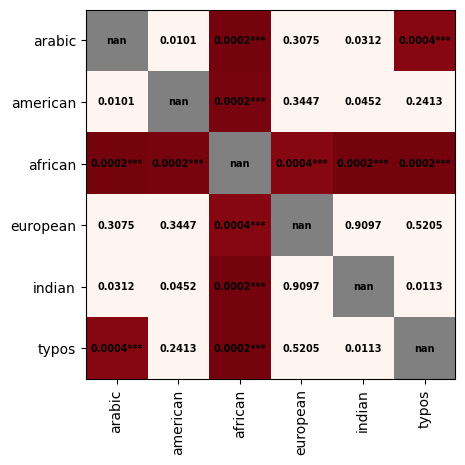

In [282]:
bonferri_correction = 0.05/(np.pow(len(conf_mat.columns),2)/2 - len(conf_mat.columns)/2)
cmap = matplotlib.colormaps['Reds'].reversed()

norm = matplotlib.colors.Normalize(vmin=0, vmax=bonferri_correction*2, clip=True)

# ax.pcolormesh(x, y, Z, vmin=0, vmax=bonferri_correction*2, cmap='Reds')
cmap.set_bad('gray',1.)

fig, ax = plt.subplots()
im = ax.imshow(conf_mat,cmap=cmap,norm=norm)

masked_array = np.ma.array (conf_mat, mask=np.isnan(conf_mat))

# Displaying a color bar to understand
# which color represents which range of data
# plt.colorbar()

# Assigning labels of x-axis 
# according to dataframe
ax.set_xticks(range(len(conf_mat)), conf_mat.columns.to_series().replace(dictionary_map), rotation=90)

# Assigning labels of y-axis 
# according to dataframe
ax.set_yticks(range(len(conf_mat)), conf_mat.index.to_series().replace(dictionary_map))


for i, col in enumerate(conf_mat.columns):
    for j, row in enumerate(conf_mat.index):
        if conf_mat.loc[col, row] == 0:
            value = np.nan
        else:
            value = round(conf_mat.loc[col, row],4)
            if value < bonferri_correction*2:
                if value < bonferri_correction:
                    if value < bonferri_correction/5:
                        asterisks = "***"
                    else:
                        asterisks = "**"
                else:
                    asterisks = "*"
            else:
                asterisks = ""
            value = str(value) + asterisks
        text = ax.text(j, i, value,
                       ha="center", va="center", color="black",size=7,fontweight="bold")

# Displaying the figure
plt.show()